<a href="https://colab.research.google.com/github/tdavenport7/IT480-FA26/blob/main/Assignment1_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer:


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


Encode your labels. We'll use integer labels (0, 1, 2) with sparse_categorical_crossentropy — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with to_categorical and use plain categorical_crossentropy instead — same result, different bookkeeping.)




In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(X3_train_scaled.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ]
)

model_multi.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

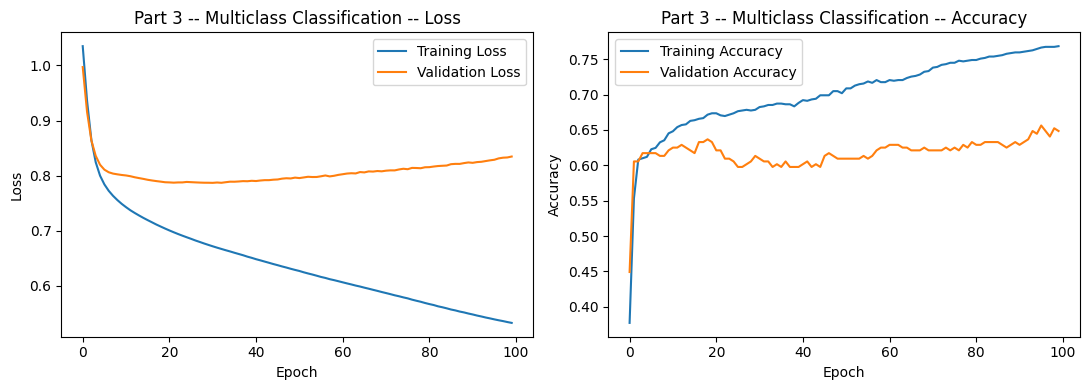

In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.653


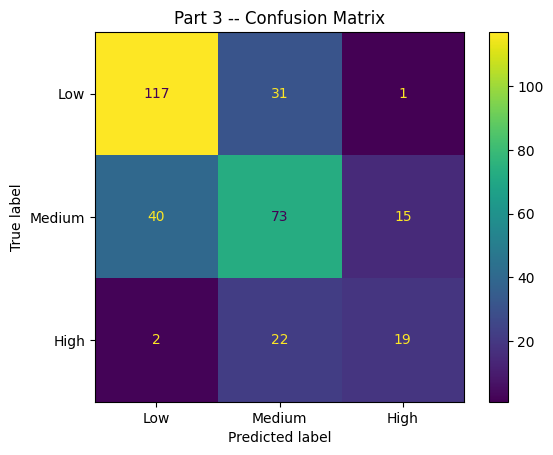

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

## Part A Baseline

My original Lab 1 multiclass model used hidden layers with 32 and 16 neurons and achieved a test accuracy of 67.81%. The loss curves showed clear overfitting because training loss decreased from approximately 0.53 to 0.38, while validation loss increased from approximately 0.81 to 0.95. The gap appeared near the beginning of training and continued widening throughout the 100 epochs. Training accuracy also increased to approximately 85%, while validation accuracy remained around 60–65%, indicating that the model learned the training data but did not generalize as effectively to validation data.

In [ ]:
!pip install keras-tuner --quiet
import keras_tuner as kt

n_features = X3_train_scaled.shape[1] # Define n_features

def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)), # Address UserWarning: use tf.keras.Input as the first layer
        tf.keras.layers.Dense(
            hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu"
        ),
        tf.keras.layers.Dense(
            hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    overwrite=True
)
tuner.search(
    X3_train_scaled, y3_train, # Changed to X3_train_scaled and y3_train
    validation_split=0.2, epochs=50, verbose=0
)
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'hidden1': 80, 'hidden2': 24, 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best hyperparameters:")
print("Hidden layer 1:", best_hp.get("hidden1"))
print("Hidden layer 2:", best_hp.get("hidden2"))
print("Learning rate:", best_hp.get("learning_rate"))
print("Best validation loss:", best_trial.score)

Best hyperparameters:
Hidden layer 1: 80
Hidden layer 2: 24
Learning rate: 0.001
Best validation loss: 0.7610486149787903


In [ ]:
tuner.results_summary()


Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 00 summary
Hyperparameters:
hidden1: 80
hidden2: 24
learning_rate: 0.001
Score: 0.7610486149787903

Trial 03 summary
Hyperparameters:
hidden1: 128
hidden2: 64
learning_rate: 0.001
Score: 0.7670863270759583

Trial 01 summary
Hyperparameters:
hidden1: 80
hidden2: 8
learning_rate: 0.001
Score: 0.772134006023407

Trial 02 summary
Hyperparameters:
hidden1: 80
hidden2: 24
learning_rate: 0.01
Score: 0.7754487991333008

Trial 06 summary
Hyperparameters:
hidden1: 80
hidden2: 64
learning_rate: 0.001
Score: 0.7791861891746521

Trial 04 summary
Hyperparameters:
hidden1: 112
hidden2: 64
learning_rate: 0.01
Score: 0.8008243441581726

Trial 08 summary
Hyperparameters:
hidden1: 32
hidden2: 24
learning_rate: 0.001
Score: 0.8024575710296631

Trial 05 summary
Hyperparameters:
hidden1: 16
hidden2: 32
learning_rate: 0.1
Score: 0.8085649609565735

Trial 09 summary
Hyperparameters:
hidden1:

## Part B Hyperparameter Tuning

I used Keras Tuner Random Search to test 10 model configurations using only the training data with a 20% validation split. The search varied the first hidden layer from 16 to 128 neurons, the second hidden layer from 8 to 64 neurons, and the Adam learning rate among 0.001, 0.01, and 0.1. The best configuration used 80 neurons in the first hidden layer, 24 neurons in the second hidden layer, and a learning rate of 0.001. It achieved a best validation loss of 0.7610. After applying the selected configuration and regularization, the final model achieved 64.06% test accuracy, which was 3.75 percentage points lower than the original 67.81% baseline.

In [ ]:
final_model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),

    tf.keras.layers.Dense(
        best_hp.get("hidden1"),
        activation="relu"
    ),

    # Dropout helps reduce overfitting and improves lucidity.
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        best_hp.get("hidden2"),
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 80)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │         1,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=17,
    restore_best_weights=True
)

In [ ]:
history_final = final_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.4673 - loss: 1.0310 - val_accuracy: 0.5547 - val_loss: 0.9429
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5552 - loss: 0.9198 - val_accuracy: 0.5898 - val_loss: 0.8743
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5709 - loss: 0.8728 - val_accuracy: 0.6211 - val_loss: 0.8424
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5689 - loss: 0.8689 - val_accuracy: 0.6211 - val_loss: 0.8279
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5787 - loss: 0.8365 - val_accuracy: 0.6289 - val_loss: 0.8167
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6266 - loss: 0.8123 - val_accuracy: 0.6289 - val_loss: 0.8084
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5973 - loss: 0.8266 - val_accuracy: 0.6328 - val_loss: 0.8020
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6217 - loss: 0.8034 - val_accuracy: 0.

In [ ]:
epochs_completed = len(history_final.history["loss"])
best_epoch = np.argmin(history_final.history["val_loss"]) + 1
best_val_loss = min(history_final.history["val_loss"])

print("Training stopped after:", epochs_completed, "epochs")
print("Best validation epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Training stopped after: 54 epochs
Best validation epoch: 37
Best validation loss: 0.7689090371131897


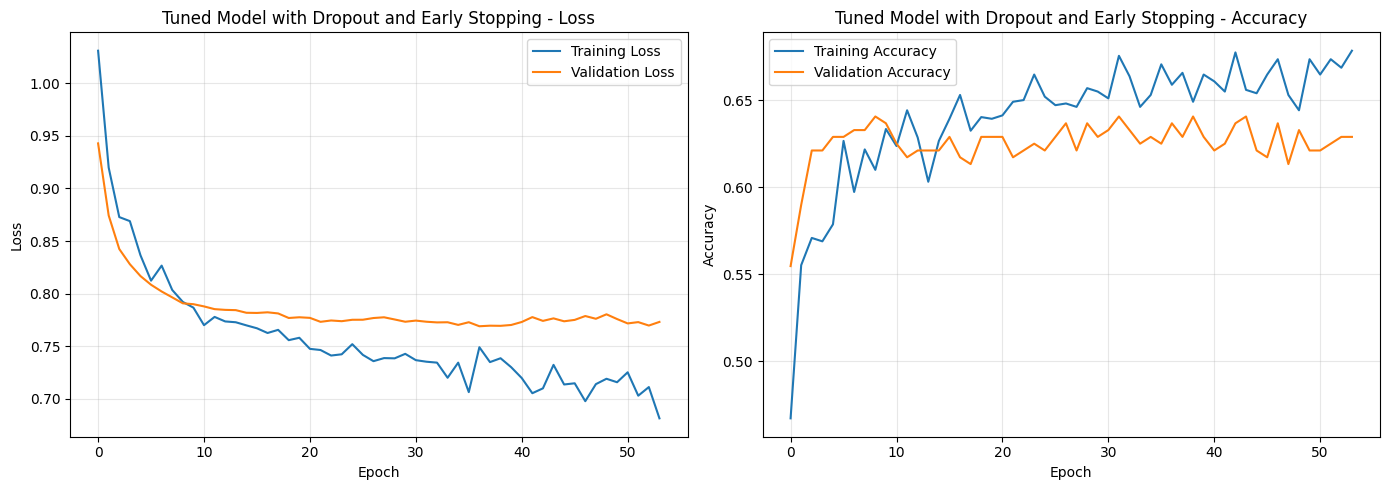

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_final.history["loss"],
    label="Training Loss"
)
axes[0].plot(
    history_final.history["val_loss"],
    label="Validation Loss"
)
axes[0].set_title("Tuned Model with Dropout and Early Stopping - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_final.history["accuracy"],
    label="Training Accuracy"
)
axes[1].plot(
    history_final.history["val_accuracy"],
    label="Validation Accuracy"
)
axes[1].set_title("Tuned Model with Dropout and Early Stopping - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_index = np.argmin(history_final.history["val_loss"])

train_loss_at_best = history_final.history["loss"][best_index]
val_loss_at_best = history_final.history["val_loss"][best_index]

train_accuracy_at_best = history_final.history["accuracy"][best_index]
val_accuracy_at_best = history_final.history["val_accuracy"][best_index]

loss_gap = val_loss_at_best - train_loss_at_best
accuracy_gap = train_accuracy_at_best - val_accuracy_at_best

print(f"Best epoch: {best_index + 1}")
print(f"Training loss at best epoch: {train_loss_at_best:.4f}")
print(f"Validation loss at best epoch: {val_loss_at_best:.4f}")
print(f"Loss gap: {loss_gap:.4f}")
print(f"Training accuracy: {train_accuracy_at_best:.4f}")
print(f"Validation accuracy: {val_accuracy_at_best:.4f}")
print(f"Accuracy gap: {accuracy_gap:.4f}")

Best epoch: 37
Training loss at best epoch: 0.7490
Validation loss at best epoch: 0.7689
Loss gap: 0.0200
Training accuracy: 0.6588
Validation accuracy: 0.6367
Accuracy gap: 0.0221


In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

y3_prob_final = final_model.predict(X3_test_scaled, verbose=0)
y3_pred_final = np.argmax(y3_prob_final, axis=1)
cm_final = confusion_matrix(y3_test, y3_pred_final)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Final test percentage: {test_accuracy * 100:.2f}%")
print("Final confusion matrix:")
print(cm_final)

Final test loss: 0.7041
Final test accuracy: 0.6406
Final test percentage: 64.06%
Final confusion matrix:
[[118  30   1]
 [ 40  73  15]
 [  0  29  14]]


## Part C Addressing Overfitting

I added a Dropout rate of 0.30 after each hidden layer and used Early Stopping with a patience of 17 epochs and `restore_best_weights=True`. Training stopped after 54 epochs, and the lowest validation loss of 0.7689 occurred at epoch 37. At the best epoch, training loss was 0.7490 and validation loss was 0.7689, resulting in a gap of only 0.0200 compared with approximately 0.57 for the original model. Validation loss flattened near 0.77 instead of continuously increasing toward 0.95, showing that Dropout and Early Stopping substantially reduced overfitting. However, the final test accuracy was 64.06%, suggesting that the regularized model may have slightly underfit the data.

The final confusion matrix was:

```text
[[118, 30,  1],
 [ 40, 73, 15],
 [  0, 29, 14]]
```

The most common error was Medium wines being predicted as Low, which occurred 40 times. Low-to-Medium errors decreased from 39 to 30, but Medium-to-Low errors increased from 32 to 40, and High-to-Medium errors increased from 21 to 29. Therefore, the model improved its recognition of the Low class but became less successful at recognizing the Medium and High classes.

## Part D Reflection

It was important to touch the test set only once because it needed to remain an unbiased measurement of performance on genuinely unseen data. If I had used the test set to select hyperparameters, information from that set would have influenced model selection and made the reported performance overly optimistic. Dropout and Early Stopping meaningfully reduced overfitting because the loss gap decreased from approximately 0.57 to 0.0200 and validation loss flattened instead of rising throughout training. However, final test accuracy decreased from 67.81% to 64.06%, indicating that the regularized model traded some predictive performance for more consistent training and validation behavior. With unlimited time and computing resources, I would tune the Dropout rate and patience value, test class weights for the smaller High class, explore different batch sizes and architectures, and use repeated stratified validation.